## 0. Imports & Configuration

In [1]:
import json
import os
import re
import math
import random
import pickle
import warnings
from collections import Counter
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import classification_report, accuracy_score, f1_score

from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

CFG = {
    # Dataset
    'reviews_per_category': 12000,   # ~12k per category -> ~36k total
    'train_ratio': 0.70,
    'val_ratio':   0.15,
    'test_ratio':  0.15,

    # Preprocessing
    'max_seq_len': 128,              # fixed max sequence length
    'vocab_size': 15000,             # top-N tokens
    'min_freq': 2,                   # minimum token frequency

    # Encoder (Part A)
    'embed_dim': 128,
    'num_heads': 4,
    'num_enc_layers': 3,
    'ff_dim': 256,
    'dropout': 0.1,
    'enc_lr': 3e-4,
    'enc_epochs': 8,
    'enc_batch_size': 64,

    # Retrieval (Part B)
    'top_k': 3,                      # number of retrieved examples

    # Decoder (Part C)
    'num_dec_layers': 2,
    'dec_lr': 3e-4,
    'dec_epochs': 6,
    'dec_batch_size': 32,
    'max_gen_len': 60,               # max tokens to generate
}

print('Configuration loaded.')
print(json.dumps(CFG, indent=2))

Device: cuda
Configuration loaded.
{
  "reviews_per_category": 12000,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "max_seq_len": 128,
  "vocab_size": 15000,
  "min_freq": 2,
  "embed_dim": 128,
  "num_heads": 4,
  "num_enc_layers": 3,
  "ff_dim": 256,
  "dropout": 0.1,
  "enc_lr": 0.0003,
  "enc_epochs": 8,
  "enc_batch_size": 64,
  "top_k": 3,
  "num_dec_layers": 2,
  "dec_lr": 0.0003,
  "dec_epochs": 6,
  "dec_batch_size": 32,
  "max_gen_len": 60
}


## 1. Dataset Loading

We load three product categories from the Amazon Reviews dataset,  **Sports & Outdoors**, **Cell Phones & Accessories**, and **Beauty**, sampling ~12,000 reviews each for a total of ~36,000. Each sample retains its `reviewText` and `overall` star rating.

In [2]:
def load_category(path: str, n: int, category_name: str) -> List[Dict]:
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            text = obj.get('reviewText', '').strip()
            rating = obj.get('overall', None)
            if text and rating is not None:
                records.append({
                    'text': text,
                    'rating': float(rating),
                    'category': category_name
                })
            if len(records) >= n:
                break
    print(f'  Loaded {len(records):,} reviews from {category_name}')
    return records


FILES = {
    'Sports_and_Outdoors':          'Sports_and_Outdoors_5.json',
    'Cell_Phones_and_Accessories':  'Cell_Phones_and_Accessories_5.json',
    'Beauty':                       'Beauty_5.json',
}

print('Loading dataset...')
all_reviews = []
for cat_name, fname in FILES.items():
    all_reviews.extend(load_category(fname, CFG['reviews_per_category'], cat_name))

random.shuffle(all_reviews)
print(f'\nTotal reviews: {len(all_reviews):,}')

# Category distribution
cat_counts = Counter(r['category'] for r in all_reviews)
print('Category distribution:', dict(cat_counts))

# Rating distribution
rating_counts = Counter(int(r['rating']) for r in all_reviews)
print('Rating distribution:', dict(sorted(rating_counts.items())))

Loading dataset...
  Loaded 12,000 reviews from Sports_and_Outdoors
  Loaded 12,000 reviews from Cell_Phones_and_Accessories
  Loaded 12,000 reviews from Beauty

Total reviews: 36,000
Category distribution: {'Sports_and_Outdoors': 12000, 'Cell_Phones_and_Accessories': 12000, 'Beauty': 12000}
Rating distribution: {1: 2250, 2: 1954, 3: 3439, 4: 6867, 5: 21490}


## 2. Preprocessing Pipeline

### Design Decisions
1. **Text Cleaning** - lower-case, remove HTML tags, strip non-ASCII, collapse whitespace.
2. **Tokenization** - simple whitespace + punctuation split (no NLTK/spaCy dependency).
3. **Vocabulary** - built from the training split only, keeping the top `vocab_size` tokens with frequency ≥ `min_freq`. Special tokens: `<PAD>` (0), `<UNK>` (1), `<BOS>` (2), `<EOS>` (3).
4. **Encoding** - each token string mapped to its integer index.
5. **Padding / Truncation** - all sequences padded or truncated to `max_seq_len`.

In [3]:
def rating_to_sentiment(rating: float) -> int:
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

def text_length_class(text: str) -> int:
    n = len(text.split())
    if n < 50:
        return 0
    elif n <= 150:
        return 1
    else:
        return 2


_HTML_TAG = re.compile(r'<[^>]+>')
_PUNCT    = re.compile(r"([!\"#$%&\'()*+,\-./:;<=>?@[\\\]^_`{|}~])")
_MULTI_SP = re.compile(r'\s+')

def clean_text(text: str) -> str:
    text = text.lower()
    text = _HTML_TAG.sub(' ', text)              # remove HTML
    text = text.encode('ascii', 'ignore').decode()  # strip non-ASCII
    text = _PUNCT.sub(r' \1 ', text)            # space around punctuation
    text = _MULTI_SP.sub(' ', text).strip()     # collapse whitespace
    return text


PAD, UNK, BOS, EOS = '<PAD>', '<UNK>', '<BOS>', '<EOS>'

class Vocabulary:
    def __init__(self, max_size: int = 15000, min_freq: int = 2):
        self.max_size = max_size
        self.min_freq = min_freq
        self.token2id: Dict[str, int] = {}
        self.id2token: Dict[int, str] = {}

    def build(self, texts: List[str]):
        counter = Counter()
        for t in texts:
            counter.update(clean_text(t).split())
        specials = [PAD, UNK, BOS, EOS]
        vocab = specials[:]
        for tok, freq in counter.most_common(self.max_size - len(specials)):
            if freq >= self.min_freq:
                vocab.append(tok)
        self.token2id = {t: i for i, t in enumerate(vocab)}
        self.id2token = {i: t for t, i in self.token2id.items()}
        print(f'  Vocabulary size: {len(self.token2id):,}')

    def encode(self, text: str, max_len: int, add_bos: bool = False, add_eos: bool = False) -> List[int]:
        tokens = clean_text(text).split()
        ids = []
        if add_bos:
            ids.append(self.token2id[BOS])
        for tok in tokens:
            ids.append(self.token2id.get(tok, self.token2id[UNK]))
        if add_eos:
            ids.append(self.token2id[EOS])
        # Truncate (preserve BOS/EOS)
        if len(ids) > max_len:
            if add_eos:
                ids = ids[:max_len - 1] + [self.token2id[EOS]]
            else:
                ids = ids[:max_len]
        # Pad
        ids += [self.token2id[PAD]] * (max_len - len(ids))
        return ids

    def decode(self, ids: List[int], skip_special: bool = True) -> str:
        skip = {self.token2id[t] for t in [PAD, UNK, BOS, EOS]} if skip_special else set()
        return ' '.join(self.id2token.get(i, UNK) for i in ids if i not in skip)

    @property
    def pad_id(self): return self.token2id[PAD]
    @property
    def unk_id(self): return self.token2id[UNK]
    @property
    def bos_id(self): return self.token2id[BOS]
    @property
    def eos_id(self): return self.token2id[EOS]
    def __len__(self):  return len(self.token2id)


n_total = len(all_reviews)
n_train = int(n_total * CFG['train_ratio'])
n_val   = int(n_total * CFG['val_ratio'])
n_test  = n_total - n_train - n_val

train_data = all_reviews[:n_train]
val_data   = all_reviews[n_train:n_train + n_val]
test_data  = all_reviews[n_train + n_val:]

print(f'Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}')

# Build vocabulary on training texts only
print('Building vocabulary from training data...')
vocab = Vocabulary(max_size=CFG['vocab_size'], min_freq=CFG['min_freq'])
vocab.build([r['text'] for r in train_data])

# Save vocab
with open('results/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print('Vocabulary saved to results/vocab.pkl')

Train: 25,200 | Val: 5,400 | Test: 5,400
Building vocabulary from training data...
  Vocabulary size: 15,000
Vocabulary saved to results/vocab.pkl


## 3. PyTorch Datasets

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, records, vocab: Vocabulary, max_len: int):
        self.samples = []
        for r in records:
            ids = vocab.encode(r['text'], max_len)
            sent = rating_to_sentiment(r['rating'])
            lenc = text_length_class(r['text'])
            self.samples.append((ids, sent, lenc))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ids, sent, lenc = self.samples[idx]
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(sent, dtype=torch.long),
            torch.tensor(lenc, dtype=torch.long),
        )


print('Creating encoder datasets...')
enc_train_ds = ReviewDataset(train_data, vocab, CFG['max_seq_len'])
enc_val_ds   = ReviewDataset(val_data,   vocab, CFG['max_seq_len'])
enc_test_ds  = ReviewDataset(test_data,  vocab, CFG['max_seq_len'])

enc_train_loader = DataLoader(enc_train_ds, batch_size=CFG['enc_batch_size'], shuffle=True)
enc_val_loader   = DataLoader(enc_val_ds,   batch_size=CFG['enc_batch_size'], shuffle=False)
enc_test_loader  = DataLoader(enc_test_ds,  batch_size=CFG['enc_batch_size'], shuffle=False)

print(f'Train batches: {len(enc_train_loader)} | Val batches: {len(enc_val_loader)} | Test batches: {len(enc_test_loader)}')

Creating encoder datasets...
Train batches: 394 | Val batches: 85 | Test batches: 85


## Part A: Encoder-Only Transformer

### Architecture
1. **Token Embedding** + **Positional Encoding** (sinusoidal, fixed)
2. **Scaled Dot-Product Attention** - implemented manually
3. **Multi-Head Attention** - `num_heads` independent heads whose outputs are concatenated and projected
4. **Encoder Block** - Multi-Head Attention -> Add & Norm -> Feed-Forward -> Add & Norm
5. **Stacked Encoder** - `num_enc_layers` blocks
6. **CLS-token pooling** -> two classification heads (sentiment, length class)

In [5]:
# Positional Encoding

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)          # (max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()  # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                        # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# Scaled Dot-Product Attention

def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    mask: Optional[torch.Tensor] = None
) -> Tuple[torch.Tensor, torch.Tensor]:
    d_k = q.size(-1)
    # Similarity scores
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, T, T)
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    attn_weights = F.softmax(scores, dim=-1)
    attn_weights = torch.nan_to_num(attn_weights, nan=0.0)  # handle all-masked rows
    context = torch.matmul(attn_weights, v)                 # (B, H, T, d_k)
    return context, attn_weights


# Multi-Head Attention

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Separate linear projections for Q, K, V (one per head effectively
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)  ->  (B, heads, T, d_k)
        B, T, _ = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, heads, T, d_k)  ->  (B, T, d_model)
        B, _, T, _ = x.size()
        return x.transpose(1, 2).contiguous().view(B, T, self.num_heads * self.d_k)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        # Project
        Q = self._split_heads(self.W_q(query))  # (B, H, T, d_k)
        K = self._split_heads(self.W_k(key))
        V = self._split_heads(self.W_v(value))

        # Attend (each head independently)
        context, _ = scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads and project output
        out = self._merge_heads(context)         # (B, T, d_model)
        return self.W_o(out)


# Position-wise Feed-Forward

class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# Encoder Block

class EncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.mha   = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff    = FeedForward(d_model, d_ff, dropout)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, src_key_padding_mask=None):
        # Padding mask: (B, T) bool -> reshape for attention: (B, 1, 1, T)
        mask = None
        if src_key_padding_mask is not None:
            mask = src_key_padding_mask.unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

        # Self-attention sub-layer with residual
        normed = self.norm1(x)
        x = x + self.drop(self.mha(normed, normed, normed, mask))

        # Feed-forward sub-layer with residual
        x = x + self.ff(self.norm2(x))
        return x


# Full Encoder Model

class EncoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        d_ff: int,
        max_seq_len: int,
        dropout: float,
        pad_id: int,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model

        # Input representation
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.scale = math.sqrt(d_model)
        self.pos_enc = PositionalEncoding(d_model, max_seq_len + 1, dropout)

        # Stacked encoder blocks
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

        # Task heads (shared encoder, two separate classifiers)
        self.sentiment_head = nn.Linear(d_model, 3)
        self.length_head    = nn.Linear(d_model, 3)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x: torch.Tensor):
        # x: (B, T)  integer token ids
        pad_mask = (x == self.pad_id)              # (B, T) True where padded

        # Embedding + positional encoding
        e = self.embed(x) * self.scale             # (B, T, d_model)
        e = self.pos_enc(e)

        # Pass through encoder stack
        for layer in self.layers:
            e = layer(e, src_key_padding_mask=pad_mask)
        e = self.norm(e)                           # (B, T, d_model)

        # Mean-pool over non-padding positions
        non_pad = (~pad_mask).unsqueeze(-1).float()  # (B, T, 1)
        pooled = (e * non_pad).sum(dim=1) / non_pad.sum(dim=1).clamp(min=1)  # (B, d_model)

        sent_logits = self.sentiment_head(pooled)  # (B, 3)
        len_logits  = self.length_head(pooled)     # (B, 3)

        return sent_logits, len_logits, pooled


# Instantiate model

encoder = EncoderTransformer(
    vocab_size  = len(vocab),
    d_model     = CFG['embed_dim'],
    num_heads   = CFG['num_heads'],
    num_layers  = CFG['num_enc_layers'],
    d_ff        = CFG['ff_dim'],
    max_seq_len = CFG['max_seq_len'],
    dropout     = CFG['dropout'],
    pad_id      = vocab.pad_id,
).to(DEVICE)

n_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f'Encoder parameters: {n_params:,}')
print(encoder)

Encoder parameters: 2,316,934
EncoderTransformer(
  (embed): Embedding(15000, 128, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layers): ModuleList(
    (0-2): 3 x EncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=False)
        (W_k): Linear(in_features=128, out_features=128, bias=False)
        (W_v): Linear(in_features=128, out_features=128, bias=False)
        (W_o): Linear(in_features=128, out_features=128, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=128, b

### Part A - Training the Encoder

In [6]:
# Loss & Optimizer

enc_optimizer = Adam(encoder.parameters(), lr=CFG['enc_lr'], weight_decay=1e-5)
enc_scheduler = CosineAnnealingLR(enc_optimizer, T_max=CFG['enc_epochs'], eta_min=1e-5)
ce_loss = nn.CrossEntropyLoss()

# Combined loss: equal weighting of both tasks
ALPHA = 0.7   # weight for sentiment (primary task)
BETA  = 0.3   # weight for length class (auxiliary task)


def run_encoder_epoch(loader, training=True):
    encoder.train(training)
    total_loss = total_sent_loss = total_len_loss = 0.0
    all_sent_preds, all_sent_true = [], []
    all_len_preds,  all_len_true  = [], []

    with torch.set_grad_enabled(training):
        for ids, sent_lbl, len_lbl in tqdm(loader, leave=False,
                                           desc='train' if training else 'eval'):
            ids      = ids.to(DEVICE)
            sent_lbl = sent_lbl.to(DEVICE)
            len_lbl  = len_lbl.to(DEVICE)

            sent_logits, len_logits, _ = encoder(ids)

            loss_sent = ce_loss(sent_logits, sent_lbl)
            loss_len  = ce_loss(len_logits,  len_lbl)
            loss      = ALPHA * loss_sent + BETA * loss_len

            if training:
                enc_optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
                enc_optimizer.step()

            total_loss      += loss.item()
            total_sent_loss += loss_sent.item()
            total_len_loss  += loss_len.item()

            all_sent_preds.extend(sent_logits.argmax(-1).cpu().tolist())
            all_sent_true.extend(sent_lbl.cpu().tolist())
            all_len_preds.extend(len_logits.argmax(-1).cpu().tolist())
            all_len_true.extend(len_lbl.cpu().tolist())

    n = len(loader)
    sent_acc = accuracy_score(all_sent_true, all_sent_preds)
    len_acc  = accuracy_score(all_len_true,  all_len_preds)
    return (
        total_loss / n, total_sent_loss / n, total_len_loss / n,
        sent_acc, len_acc
    )


# Training Loop

enc_history = {
    'train_loss': [], 'val_loss': [],
    'train_sent_acc': [], 'val_sent_acc': [],
    'train_len_acc':  [], 'val_len_acc':  [],
}

best_val_loss = float('inf')

print('Training Encoder...')
print(f'  Epochs: {CFG["enc_epochs"]} | Batch: {CFG["enc_batch_size"]} | LR: {CFG["enc_lr"]}')
print(f'  Combined loss weight: sentiment={ALPHA}, length={BETA}')
print('-' * 75)

for epoch in range(1, CFG['enc_epochs'] + 1):
    tr = run_encoder_epoch(enc_train_loader, training=True)
    vl = run_encoder_epoch(enc_val_loader,   training=False)
    enc_scheduler.step()

    enc_history['train_loss'].append(tr[0])
    enc_history['val_loss'].append(vl[0])
    enc_history['train_sent_acc'].append(tr[3])
    enc_history['val_sent_acc'].append(vl[3])
    enc_history['train_len_acc'].append(tr[4])
    enc_history['val_len_acc'].append(vl[4])

    print(f'Epoch {epoch:02d}/{CFG["enc_epochs"]} | '
          f'Train Loss: {tr[0]:.4f} (sent={tr[1]:.4f}, len={tr[2]:.4f}) | '
          f'Val Loss: {vl[0]:.4f} | '
          f'Train SentAcc: {tr[3]:.3f} | Val SentAcc: {vl[3]:.3f} | '
          f'Val LenAcc: {vl[4]:.3f}')

    if vl[0] < best_val_loss:
        best_val_loss = vl[0]
        torch.save(encoder.state_dict(), 'models/encoder_best.pt')

print(f'\nBest val loss: {best_val_loss:.4f} | Saved -> models/encoder_best.pt')

Training Encoder...
  Epochs: 8 | Batch: 64 | LR: 0.0003
  Combined loss weight: sentiment=0.7, length=0.3
---------------------------------------------------------------------------


Epoch 01/8 | Train Loss: 0.4684 (sent=0.5627, len=0.2484) | Val Loss: 0.4257 | Train SentAcc: 0.803 | Val SentAcc: 0.820 | Val LenAcc: 0.869


Epoch 02/8 | Train Loss: 0.3493 (sent=0.4175, len=0.1900) | Val Loss: 0.4169 | Train SentAcc: 0.844 | Val SentAcc: 0.822 | Val LenAcc: 0.873


Epoch 03/8 | Train Loss: 0.2636 (sent=0.3165, len=0.1403) | Val Loss: 0.4839 | Train SentAcc: 0.877 | Val SentAcc: 0.819 | Val LenAcc: 0.891


Epoch 04/8 | Train Loss: 0.1700 (sent=0.2042, len=0.0900) | Val Loss: 0.5973 | Train SentAcc: 0.925 | Val SentAcc: 0.805 | Val LenAcc: 0.883


Epoch 05/8 | Train Loss: 0.0998 (sent=0.1180, len=0.0573) | Val Loss: 0.8364 | Train SentAcc: 0.958 | Val SentAcc: 0.798 | Val LenAcc: 0.881


Epoch 06/8 | Train Loss: 0.0609 (sent=0.0722, len=0.0345) | Val Loss: 0.9943 | Train SentAcc: 0.975 | Val SentAcc: 0.792 | Val LenAcc: 0.881


Epoch 07/8 | Train Loss: 0.0406 (sent=0.0480, len=0.0234) | Val Loss: 1.0761 | Train SentAcc: 0.984 | Val SentAcc: 0.794 | Val LenAcc: 0.878


Epoch 08/8 | Train Loss: 0.0295 (sent=0.0339, len=0.0194) | Val Loss: 1.1375 | Train SentAcc: 0.988 | Val SentAcc: 0.792 | Val LenAcc: 0.880

Best val loss: 0.4169 | Saved -> models/encoder_best.pt


### Part A - Learning Curves

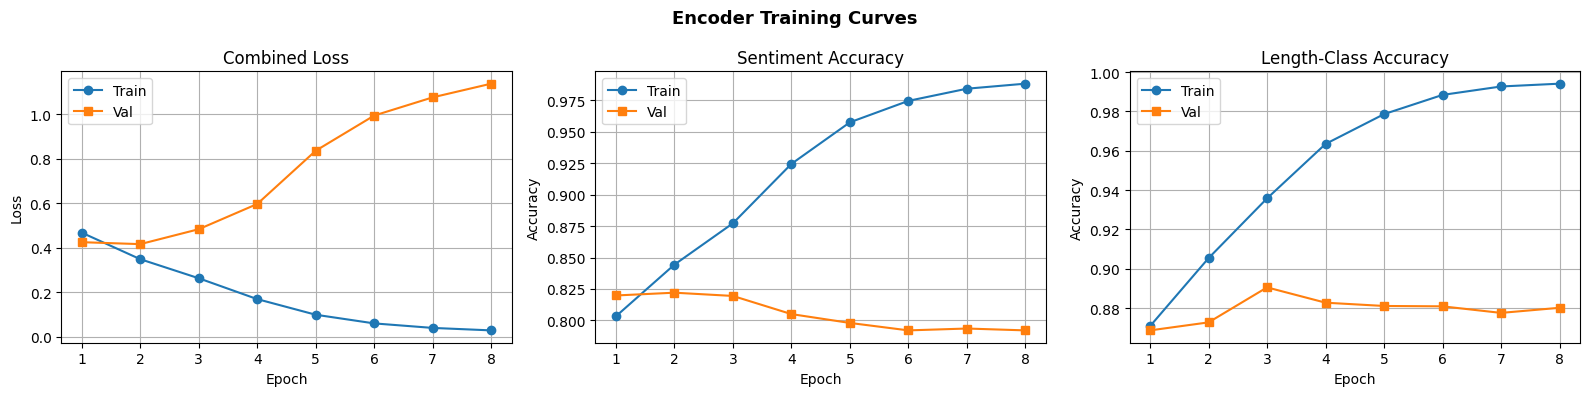

Saved -> results/encoder_learning_curves.png


In [7]:
epochs_range = range(1, CFG['enc_epochs'] + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Encoder Training Curves', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(epochs_range, enc_history['train_loss'], label='Train', marker='o')
ax.plot(epochs_range, enc_history['val_loss'],   label='Val',   marker='s')
ax.set_title('Combined Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(epochs_range, enc_history['train_sent_acc'], label='Train', marker='o')
ax.plot(epochs_range, enc_history['val_sent_acc'],   label='Val',   marker='s')
ax.set_title('Sentiment Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)

ax = axes[2]
ax.plot(epochs_range, enc_history['train_len_acc'], label='Train', marker='o')
ax.plot(epochs_range, enc_history['val_len_acc'],   label='Val',   marker='s')
ax.set_title('Length-Class Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', bbox_inches='tight')
plt.show()
print('Saved -> results/encoder_learning_curves.png')

### Part A - Test Set Evaluation

In [8]:
# Load best checkpoint
encoder.load_state_dict(torch.load('models/encoder_best.pt', map_location=DEVICE))
encoder.eval()

all_sent_preds, all_sent_true = [], []
all_len_preds,  all_len_true  = [], []

with torch.no_grad():
    for ids, sent_lbl, len_lbl in tqdm(enc_test_loader, desc='Testing'):
        ids = ids.to(DEVICE)
        sp, lp, _ = encoder(ids)
        all_sent_preds.extend(sp.argmax(-1).cpu().tolist())
        all_sent_true.extend(sent_lbl.tolist())
        all_len_preds.extend(lp.argmax(-1).cpu().tolist())
        all_len_true.extend(len_lbl.tolist())

SENTIMENT_LABELS = ['Negative', 'Neutral', 'Positive']
LENGTH_LABELS    = ['Short', 'Medium', 'Long']

print('=' * 60)
print('TASK 1 - Sentiment Classification')
print('=' * 60)
print(classification_report(all_sent_true, all_sent_preds, target_names=SENTIMENT_LABELS))

print('=' * 60)
print('TASK 2 - Review Length Classification (Derived Feature)')
print('=' * 60)
print(classification_report(all_len_true, all_len_preds, target_names=LENGTH_LABELS))

sent_f1 = f1_score(all_sent_true, all_sent_preds, average='macro')
len_f1  = f1_score(all_len_true,  all_len_preds,  average='macro')
print(f'Sentiment Macro-F1: {sent_f1:.4f} | Length Macro-F1: {len_f1:.4f}')

# Save results
with open('results/encoder_test_metrics.json', 'w') as f:
    json.dump({'sentiment_macro_f1': sent_f1, 'length_macro_f1': len_f1}, f, indent=2)
print('Metrics saved -> results/encoder_test_metrics.json')

Testing: 100%|██████████| 85/85 [00:00<00:00, 111.92it/s]

TASK 1 - Sentiment Classification
              precision    recall  f1-score   support

    Negative       0.58      0.52      0.55       628
     Neutral       0.52      0.07      0.13       547
    Positive       0.86      0.97      0.91      4225

    accuracy                           0.83      5400
   macro avg       0.65      0.52      0.53      5400
weighted avg       0.79      0.83      0.79      5400

TASK 2 - Review Length Classification (Derived Feature)
              precision    recall  f1-score   support

       Short       0.94      1.00      0.97      2558
      Medium       0.99      0.67      0.80      2036
        Long       0.61      0.99      0.76       806

    accuracy                           0.87      5400
   macro avg       0.85      0.89      0.84      5400
weighted avg       0.91      0.87      0.87      5400

Sentiment Macro-F1: 0.5306 | Length Macro-F1: 0.8415
Metrics saved -> results/encoder_test_metrics.json


### Part A - Save Embeddings for Retrieval

In [9]:
def extract_embeddings(loader, desc='Extracting'):
    encoder.eval()
    embeddings = []
    with torch.no_grad():
        for ids, _, _ in tqdm(loader, desc=desc):
            ids = ids.to(DEVICE)
            _, _, emb = encoder(ids)
            embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)


print('Extracting training set embeddings...')
train_embeddings = extract_embeddings(enc_train_loader, 'Train embeds')
print(f'Shape: {train_embeddings.shape}')

print('Extracting test set embeddings...')
test_embeddings = extract_embeddings(enc_test_loader, 'Test embeds')
print(f'Shape: {test_embeddings.shape}')

# Normalise embeddings (L2) for cosine similarity via dot product
def l2_normalize(x: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(x, axis=1, keepdims=True).clip(min=1e-8)
    return x / norms

train_embeddings_norm = l2_normalize(train_embeddings)
test_embeddings_norm  = l2_normalize(test_embeddings)

np.save('results/train_embeddings.npy', train_embeddings_norm)
np.save('results/test_embeddings.npy',  test_embeddings_norm)
print('Embeddings saved -> results/train_embeddings.npy')
print('Embeddings saved -> results/test_embeddings.npy')

Extracting training set embeddings...


Train embeds: 100%|██████████| 394/394 [00:03<00:00, 109.54it/s]


Shape: (25200, 128)
Extracting test set embeddings...


Test embeds: 100%|██████████| 85/85 [00:00<00:00, 109.52it/s]

Shape: (5400, 128)
Embeddings saved -> results/train_embeddings.npy
Embeddings saved -> results/test_embeddings.npy


---
## Part B - Retrieval Module

### Design
- **Storage**: All training embeddings are L2-normalised and stored as a NumPy matrix.
- **Query**: At inference, the test review embedding (from the encoder) is L2-normalised.
- **Similarity**: Cosine similarity = dot product of L2-normalised vectors.
- **Top-k**: We retrieve the top-k most similar training reviews (k=3 by default, configurable).

**Why cosine similarity?** It measures directional similarity independent of vector magnitude, which is ideal since embeddings can vary in scale across reviews.

In [10]:
class RetrieverIndex:
    def __init__(self, embeddings: np.ndarray, records: List[Dict]):
        assert len(embeddings) == len(records)
        self.index   = embeddings   # (N, d)
        self.records = records

    def search(self, query_emb: np.ndarray, k: int = 3) -> List[Dict]:
        scores = self.index @ query_emb          # (N,) cosine sims
        top_k_idx = np.argsort(scores)[::-1][:k] # descending
        results = []
        for idx in top_k_idx:
            rec = dict(self.records[idx])
            rec['similarity'] = float(scores[idx])
            results.append(rec)
        return results


retriever = RetrieverIndex(train_embeddings_norm, train_data)
print(f'Retrieval index built: {len(train_data):,} documents indexed')
print(f'Embedding dimension: {train_embeddings_norm.shape[1]}')
print(f'Default k: {CFG["top_k"]}')

Retrieval index built: 25,200 documents indexed
Embedding dimension: 128
Default k: 3


### Part B - Retrieval Quality Analysis

In [11]:
def get_encoder_embedding(text: str) -> np.ndarray:
    ids = torch.tensor(vocab.encode(text, CFG['max_seq_len']),
                       dtype=torch.long).unsqueeze(0).to(DEVICE)
    encoder.eval()
    with torch.no_grad():
        _, _, emb = encoder(ids)
    e = emb.cpu().numpy()[0]
    return e / np.linalg.norm(e).clip(min=1e-8)


# Qualitative examples

QUERY_EXAMPLES = [
    test_data[0],
    test_data[10],
    test_data[50],
]

print('=== Retrieval Quality Examples ===')
for qi, query_rec in enumerate(QUERY_EXAMPLES):
    q_text = query_rec['text'][:200]
    q_rating = query_rec['rating']
    q_sent = ['Negative', 'Neutral', 'Positive'][rating_to_sentiment(q_rating)]

    q_emb = test_embeddings_norm[QUERY_EXAMPLES.index(query_rec)]
    results = retriever.search(q_emb, k=CFG['top_k'])

    print(f'\n--- Query {qi+1} ---')
    print(f'  Category : {query_rec["category"]}')
    print(f'  Sentiment: {q_sent} (rating={q_rating})')
    print(f'  Text     : {q_text}...')
    print(f'  Top-{CFG["top_k"]} retrieved:')
    for ri, res in enumerate(results):
        r_sent = ['Negative', 'Neutral', 'Positive'][rating_to_sentiment(res['rating'])]
        print(f'    [{ri+1}] sim={res["similarity"]:.4f} | {r_sent} | cat={res["category"]}'
              f' | {res["text"][:120]}...')

=== Retrieval Quality Examples ===

--- Query 1 ---
  Category : Sports_and_Outdoors
  Sentiment: Positive (rating=5.0)
  Text     : These bases are very nice for the price, even if they were cost a little more.They are very thick rubber, with a waffle design on the bottom. i coach my sons baseball team, and these have held up very...
  Top-3 retrieved:
    [1] sim=0.9961 | Positive | cat=Cell_Phones_and_Accessories | I was real hesitant to buy this battery. But for the price, and convenience of free shipping, I cant say that I regret i...
    [2] sim=0.9960 | Positive | cat=Cell_Phones_and_Accessories | My son's cell phone battery was dying out quickly.  After purchasing this product, he hasn't had any problems with his c...
    [3] sim=0.9957 | Positive | cat=Cell_Phones_and_Accessories | This case is good quality and arrived on time will be a good standby when I need to protect my phone doing a task....

--- Query 2 ---
  Category : Beauty
  Sentiment: Positive (rating=5.0)
  Text  

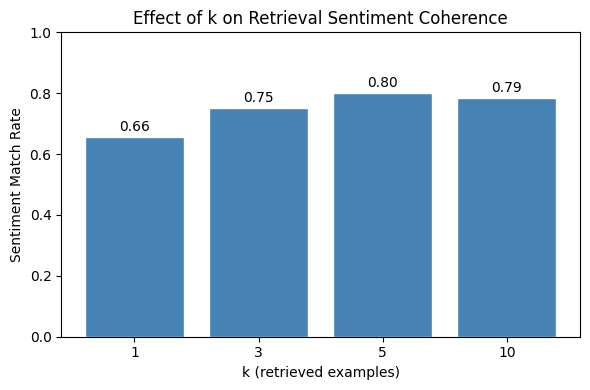

Saved -> results/retrieval_k_analysis.png

Match rates by k: {1: 0.655, 3: 0.75, 5: 0.8, 10: 0.785}


In [12]:
# Effect of k on Sentiment Match Rate

k_values = [1, 3, 5, 10]
n_eval   = 200   # evaluate on 200 test queries for speed

match_rates = []
for k_val in k_values:
    matches = 0
    for i in range(n_eval):
        q_emb = test_embeddings_norm[i]
        q_sent = rating_to_sentiment(test_data[i]['rating'])
        retrieved = retriever.search(q_emb, k=k_val)
        r_sents = [rating_to_sentiment(r['rating']) for r in retrieved]
        # Count match if majority of retrieved have the same sentiment
        if r_sents.count(q_sent) > k_val / 2:
            matches += 1
    match_rates.append(matches / n_eval)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(k) for k in k_values], match_rates, color='steelblue', edgecolor='white')
ax.set_xlabel('k (retrieved examples)')
ax.set_ylabel('Sentiment Match Rate')
ax.set_title('Effect of k on Retrieval Sentiment Coherence')
ax.set_ylim(0, 1)
for x, y in zip(range(len(k_values)), match_rates):
    ax.text(x, y + 0.01, f'{y:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('results/retrieval_k_analysis.png', bbox_inches='tight')
plt.show()
print('Saved -> results/retrieval_k_analysis.png')
print('\nMatch rates by k:', dict(zip(k_values, match_rates)))